In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

from iqwav.io import load_raw_iq

### Experiment 1 — 4s Audio

In [2]:
path = Path("../../data/external/fm_rds_250k_1Msamples.iq")

fs = 250_000

iq = load_raw_iq(
    path,
    dtype=np.float32,
    iq_order="IQ"
)

print("Samples:", len(iq))
print("Duration:", len(iq) / fs, "s")

Samples: 1000000
Duration: 4.0 s


In [3]:
## FM demodulation

from iqwav.demod import fm_demodulate

fm_demod = fm_demodulate(iq)

print("Demod samples:", len(fm_demod))
print("Min:", fm_demod.min())
print("Max:", fm_demod.max())

Demod samples: 999999
Min: -2.206136512911292
Max: 1.790591979088206


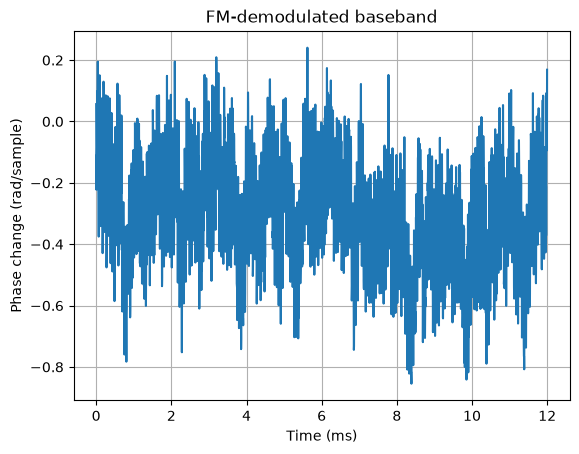

In [4]:
n = 3000
t = np.arange(n) / fs

plt.plot(t * 1000, fm_demod[:n])
plt.xlabel("Time (ms)")
plt.ylabel("Phase change (rad/sample)")
plt.title("FM-demodulated baseband")
plt.grid()
plt.show()

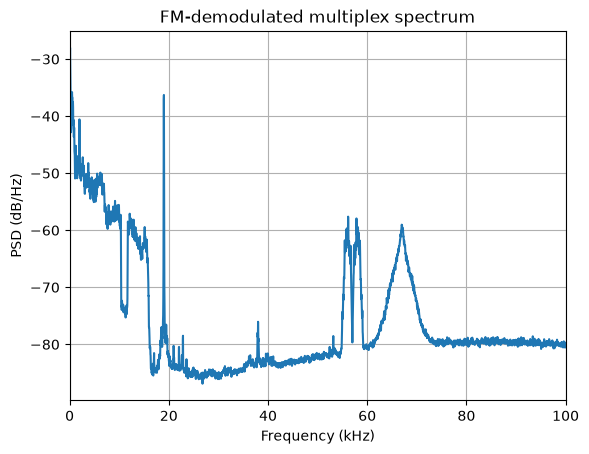

In [5]:
f, pxx = signal.welch(
    fm_demod,
    fs=fs,
    nperseg=8192
)

pxx_db = 10 * np.log10(pxx + 1e-20)

plt.plot(f / 1000, pxx_db)
plt.xlim(0, 100)

plt.xlabel("Frequency (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("FM-demodulated multiplex spectrum")
plt.grid()
plt.show()

In [6]:
## Isolate mono audio

audio_cutoff = 15_000

sos = signal.butter(
    6,
    audio_cutoff,
    btype="lowpass",
    fs=fs,
    output="sos"
)

audio = signal.sosfilt(sos, fm_demod)


audio = audio - np.mean(audio)  ## remove dc




In [7]:
## decimate

audio_50k = signal.resample_poly(
    audio,
    up=1,
    down=5
)

audio_fs = 50_000

print("Audio samples:", len(audio_50k))
print("Audio duration:", len(audio_50k) / audio_fs, "s")

Audio samples: 200000
Audio duration: 4.0 s


In [8]:
peak = np.max(np.abs(audio_50k))

if peak > 0:
    audio_50k = audio_50k / peak

audio_int16 = np.int16(
    np.clip(audio_50k, -1, 1) * 32767
)

In [10]:
output_path = Path("../../outputs/runs/fm_demod_audio.wav")

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

wavfile.write(
    output_path,
    audio_fs,
    audio_int16
)

print("Saved:", output_path.resolve())

Saved: C:\_VAULT\Techhh\IQWAV\outputs\runs\fm_demod_audio.wav


### Experiment 2 — Wideband Mumbai FM Capture

In [1]:
from pathlib import Path
import numpy as np

mumbai_path = Path("../../data/external/mumbai-10s-10M-92.3-8-10-25.iq")

fs_mumbai = 10_000_000
center_freq_mumbai = 92.3e6

file_size = mumbai_path.stat().st_size

print("File size:", file_size, "bytes")
print("complex64 samples:", file_size // 8)
print("Estimated duration:", (file_size // 8) / fs_mumbai, "s")

File size: 880590288 bytes
complex64 samples: 110073786
Estimated duration: 11.0073786 s


In [2]:
with open(mumbai_path, "rb") as f:
    iq_test = np.fromfile(f, dtype=np.complex64, count=1_000_000)

print("Shape:", iq_test.shape)
print("dtype:", iq_test.dtype)

print("First 10 samples:")
print(iq_test[:10])

print("I range:", iq_test.real.min(), iq_test.real.max())
print("Q range:", iq_test.imag.min(), iq_test.imag.max())

print("Mean magnitude:", np.mean(np.abs(iq_test)))
print("Max magnitude:", np.max(np.abs(iq_test)))

print("Finite:", np.all(np.isfinite(iq_test)))

Shape: (1000000,)
dtype: complex64
First 10 samples:
[-0.01574803-0.01574803j -0.01574803-0.01574803j -0.01574803-0.01574803j
 -0.01574803-0.01574803j -0.01574803-0.02362205j -0.01574803-0.02362205j
 -0.01574803-0.02362205j -0.00787402-0.02362205j -0.00787402-0.02362205j
 -0.01574803-0.01574803j]
I range: -0.031496063 0.0
Q range: -0.031496063 0.0
Mean magnitude: 0.021141293
Max magnitude: 0.03937008
Finite: True


In [3]:
samples_per_chunk = 1_000_000
start_seconds = 5

with open(mumbai_path, "rb") as f:
    f.seek(start_seconds * fs_mumbai * 8)   # 8 bytes per complex64 sample
    iq_mid = np.fromfile(f, dtype=np.complex64, count=samples_per_chunk)

print("Shape:", iq_mid.shape)
print("I range:", iq_mid.real.min(), iq_mid.real.max())
print("Q range:", iq_mid.imag.min(), iq_mid.imag.max())
print("I mean:", iq_mid.real.mean())
print("Q mean:", iq_mid.imag.mean())
print("Mean magnitude:", np.mean(np.abs(iq_mid)))
print("Max magnitude:", np.max(np.abs(iq_mid)))
print("Finite:", np.all(np.isfinite(iq_mid)))

Shape: (1000000,)
I range: -0.031496063 0.0
Q range: -0.031496063 0.0
I mean: -0.014881226
Q mean: -0.014429117
Mean magnitude: 0.021371424
Max magnitude: 0.03937008
Finite: True


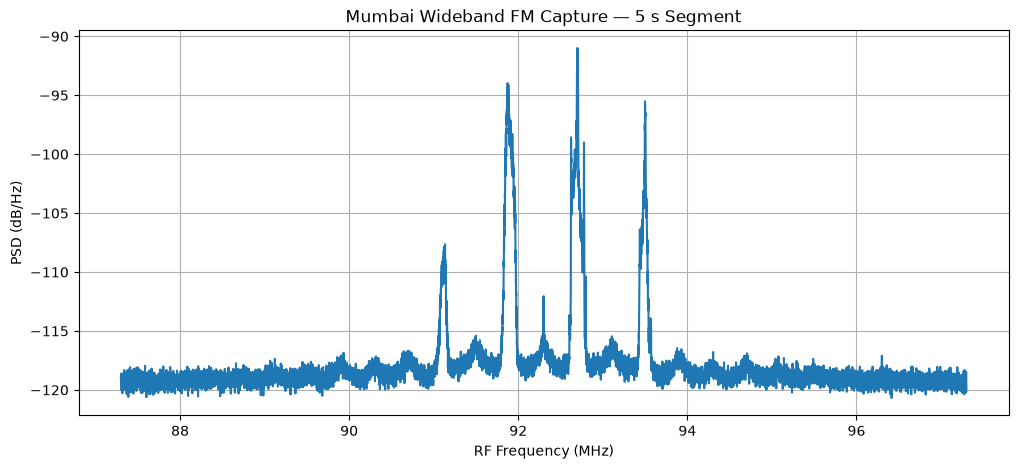

In [4]:
from scipy import signal
import matplotlib.pyplot as plt

freqs, psd = signal.welch(
    iq_mid,
    fs=fs_mumbai,
    nperseg=16384,
    return_onesided=False
)

freqs = np.fft.fftshift(freqs)
psd = np.fft.fftshift(psd)

rf_freq_mhz = (center_freq_mumbai + freqs) / 1e6

plt.figure(figsize=(12, 5))
plt.plot(rf_freq_mhz, 10 * np.log10(psd + 1e-20))
plt.xlabel("RF Frequency (MHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Mumbai Wideband FM Capture — 5 s Segment")
plt.grid(True)
plt.show()

In [5]:
iq_work = iq_mid - np.mean(iq_mid)

print("Before mean:", np.mean(iq_mid))
print("After mean :", np.mean(iq_work))

Before mean: (-0.014881226-0.014429117j)
After mean : (-2.002716e-09-1.434803e-09j)


In [6]:
target_freq = 92.7e6

freq_offset = target_freq - center_freq_mumbai

n = np.arange(len(iq_work))

iq_shifted = iq_work * np.exp(
    -1j * 2 * np.pi * freq_offset * n / fs_mumbai
)

print("Shift applied:", freq_offset / 1e3, "kHz")

Shift applied: 400.0 kHz


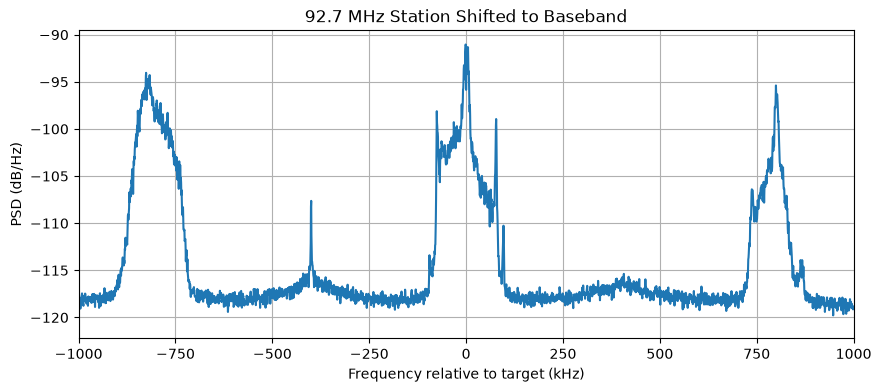

In [8]:
f_shift, p_shift = signal.welch(
    iq_shifted,
    fs=fs_mumbai,
    nperseg=16384,
    return_onesided=False
)

f_shift = np.fft.fftshift(f_shift)
p_shift = np.fft.fftshift(p_shift)

plt.figure(figsize=(10, 4))
plt.plot(
    f_shift / 1e3,
    10 * np.log10(p_shift + 1e-20)
)
plt.xlim(-1000, 1000)
plt.xlabel("Frequency relative to target (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("92.7 MHz Station Shifted to Baseband")
plt.grid(True)
plt.show()

In [9]:
iq_channel = signal.resample_poly(
    iq_shifted,
    up=1,
    down=40
)

fs_channel = fs_mumbai // 40

print("Old sample rate:", fs_mumbai)
print("New sample rate:", fs_channel)
print("Old samples:", len(iq_shifted))
print("New samples:", len(iq_channel))

Old sample rate: 10000000
New sample rate: 250000
Old samples: 1000000
New samples: 25000


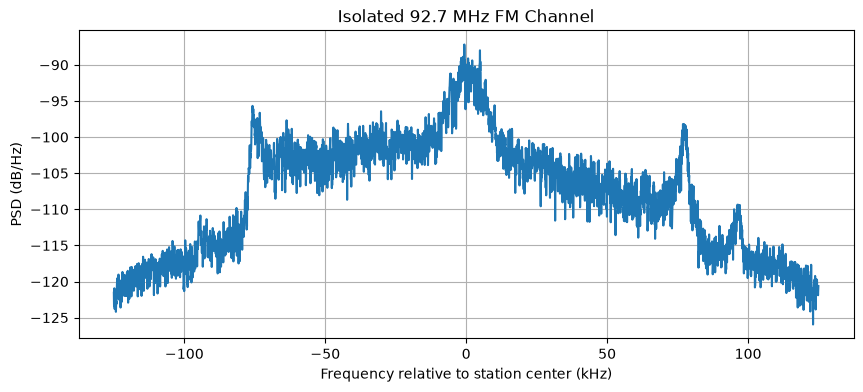

In [10]:
f_ch, p_ch = signal.welch(
    iq_channel,
    fs=fs_channel,
    nperseg=4096,
    return_onesided=False
)

f_ch = np.fft.fftshift(f_ch)
p_ch = np.fft.fftshift(p_ch)

plt.figure(figsize=(10, 4))
plt.plot(
    f_ch / 1e3,
    10 * np.log10(p_ch + 1e-20)
)

plt.xlabel("Frequency relative to station center (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Isolated 92.7 MHz FM Channel")
plt.grid(True)
plt.show()

In [11]:
from iqwav.demod import fm_demodulate

fm_mumbai = fm_demodulate(iq_channel)

print("IQ samples:", len(iq_channel))
print("FM-demod samples:", len(fm_mumbai))
print("Mean phase increment:", np.mean(fm_mumbai), "rad/sample")

IQ samples: 25000
FM-demod samples: 24999
Mean phase increment: -0.020805219344460932 rad/sample


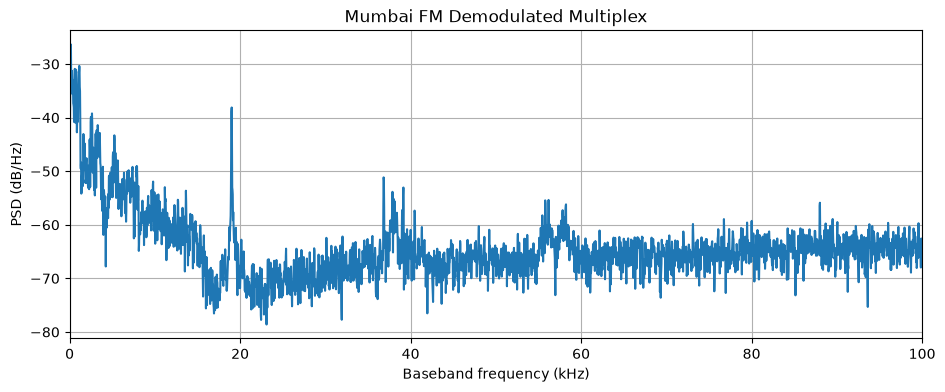

In [12]:
f_mux, p_mux = signal.welch(
    fm_mumbai,
    fs=fs_channel,
    nperseg=8192
)

plt.figure(figsize=(11, 4))
plt.plot(
    f_mux / 1e3,
    10 * np.log10(p_mux + 1e-20)
)

plt.xlim(0, 100)
plt.xlabel("Baseband frequency (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Mumbai FM Demodulated Multiplex")
plt.grid(True)
plt.show()

In [16]:
## audio

from scipy import signal
from scipy.io import wavfile
from iqwav.demod import fm_demodulate
import numpy as np

fs_wide = 10_000_000
fs_channel = 250_000

center_freq = 92.3e6
target_freq = 92.7e6
freq_offset = target_freq - center_freq

chunk_complex_samples = 10_000_000   # 1 second at 10 MS/s

audio_chunks = []

with open(mumbai_path, "rb") as f:
    sample_index = 0

    while True:
        iq_chunk = np.fromfile(
            f,
            dtype=np.complex64,
            count=chunk_complex_samples
        )

        if len(iq_chunk) == 0:
            break

        # Remove complex-IQ DC offset
        iq_chunk = iq_chunk - np.mean(iq_chunk)

        # Frequency-shift 92.7 MHz station to baseband
        n = sample_index + np.arange(len(iq_chunk))

        iq_shifted = iq_chunk * np.exp(
            -1j * 2 * np.pi * freq_offset * n / fs_wide
        )

        # Channel filtering + 10 MS/s -> 250 kS/s
        iq_channel = signal.resample_poly(
            iq_shifted,
            up=1,
            down=40
        )

        # FM phase discriminator
        fm = fm_demodulate(iq_channel)

        # Keep mono-compatible 0-15 kHz component
        sos_audio = signal.butter(
            6,
            15_000,
            btype="lowpass",
            fs=fs_channel,
            output="sos"
        )

        audio = signal.sosfilt(sos_audio, fm)

        # Remove demodulated DC
        audio = audio - np.mean(audio)

        # FM broadcast de-emphasis
        # India uses 50 microseconds
        tau = 50e-6

        b_deemph = [1.0]
        a_deemph = [tau, 1.0]

        # Analog RC response converted to a digital filter
        b_z, a_z = signal.bilinear(
            b_deemph,
            a_deemph,
            fs=fs_channel
        )

        audio = signal.lfilter(
            b_z,
            a_z,
            audio
        )

        # 250 kHz -> 50 kHz audio
        audio_50k = signal.resample_poly(
            audio,
            up=1,
            down=5
        )

        audio_chunks.append(audio_50k)

        sample_index += len(iq_chunk)

        print(
            f"Processed {sample_index / fs_wide:.2f} s"
        )

audio_full = np.concatenate(audio_chunks)

print("Audio duration:",
      len(audio_full) / 50_000,
      "seconds")

Processed 1.00 s
Processed 2.00 s
Processed 3.00 s
Processed 4.00 s
Processed 5.00 s
Processed 6.00 s
Processed 7.00 s
Processed 8.00 s
Processed 9.00 s
Processed 10.00 s
Processed 11.00 s
Processed 11.01 s
Audio duration: 11.00738 seconds


In [17]:
peak = np.max(np.abs(audio_full))

if peak > 0:
    audio_full = audio_full / peak

audio_int16 = np.int16(
    np.clip(audio_full, -1, 1) * 32767
)

In [18]:
# output_path = "../../outputs/runs/mumbai_92_7_fm_audio.wav"
output_path = "../../outputs/runs/mumbai_92_7_fm_audio_deemph.wav"

wavfile.write(
    output_path,
    50_000,
    audio_int16
)

print("Saved:", output_path)

Saved: ../../outputs/runs/mumbai_92_7_fm_audio_deemph.wav
